In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/processed/training.csv')

In [3]:
correlation_matrix = df.corr(numeric_only=True)
display(correlation_matrix['Insulator'].sort_values(ascending=False))

Insulator        1.000000
PBE_band_gap     0.897896
H-B2             0.315558
type_A2B1B2O6    0.287612
H-B1             0.287509
                   ...   
TC-B2           -0.221953
X-B2            -0.238527
X-B1            -0.238635
I-B1            -0.240538
I-B2            -0.261170
Name: Insulator, Length: 63, dtype: float64

In [4]:
from scipy.stats import pearsonr, spearmanr, kendalltau

correlation_results = {}

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('Insulator')


for col in numeric_cols:

    temp_df = df[[col, 'Insulator']].dropna()
    if len(temp_df) > 1:
        pearson_corr, _ = pearsonr(temp_df[col], temp_df['Insulator'])
        spearman_corr, _ = spearmanr(temp_df[col], temp_df['Insulator'])
        kendall_corr, _ = kendalltau(temp_df[col], temp_df['Insulator'])

        correlation_results[col] = {
            'Pearson': pearson_corr,
            'Spearman': spearman_corr,
            'Kendall': kendall_corr
        }
    else:
        correlation_results[col] = {
            'Pearson': None,
            'Spearman': None,
            'Kendall': None
        }



for col, corrs in correlation_results.items():
    print(f"Correlations with Insulator for column '{col}':")
    for method, value in corrs.items():
        print(f"  {method}: {value:.4f}" if value is not None else f"  {method}: Insufficient data")
    print("-" * 20)

Correlations with Insulator for column 'A1_OS':
  Pearson: -0.0586
  Spearman: -0.0568
  Kendall: -0.0545
--------------------
Correlations with Insulator for column 'A2_OS':
  Pearson: 0.0743
  Spearman: 0.0815
  Kendall: 0.0770
--------------------
Correlations with Insulator for column 'B1_OS':
  Pearson: -0.0557
  Spearman: -0.0738
  Kendall: -0.0681
--------------------
Correlations with Insulator for column 'B2_OS':
  Pearson: 0.0438
  Spearman: 0.0197
  Kendall: 0.0186
--------------------
Correlations with Insulator for column 'PBE_band_gap':
  Pearson: 0.8979
  Spearman: 0.8501
  Kendall: 0.7484
--------------------
Correlations with Insulator for column 'stable':
  Pearson: -0.1811
  Spearman: -0.1811
  Kendall: -0.1811
--------------------
Correlations with Insulator for column 'X-A1':
  Pearson: -0.1798
  Spearman: -0.1606
  Kendall: -0.1352
--------------------
Correlations with Insulator for column 'X-A2':
  Pearson: -0.1679
  Spearman: -0.1326
  Kendall: -0.1114
--------

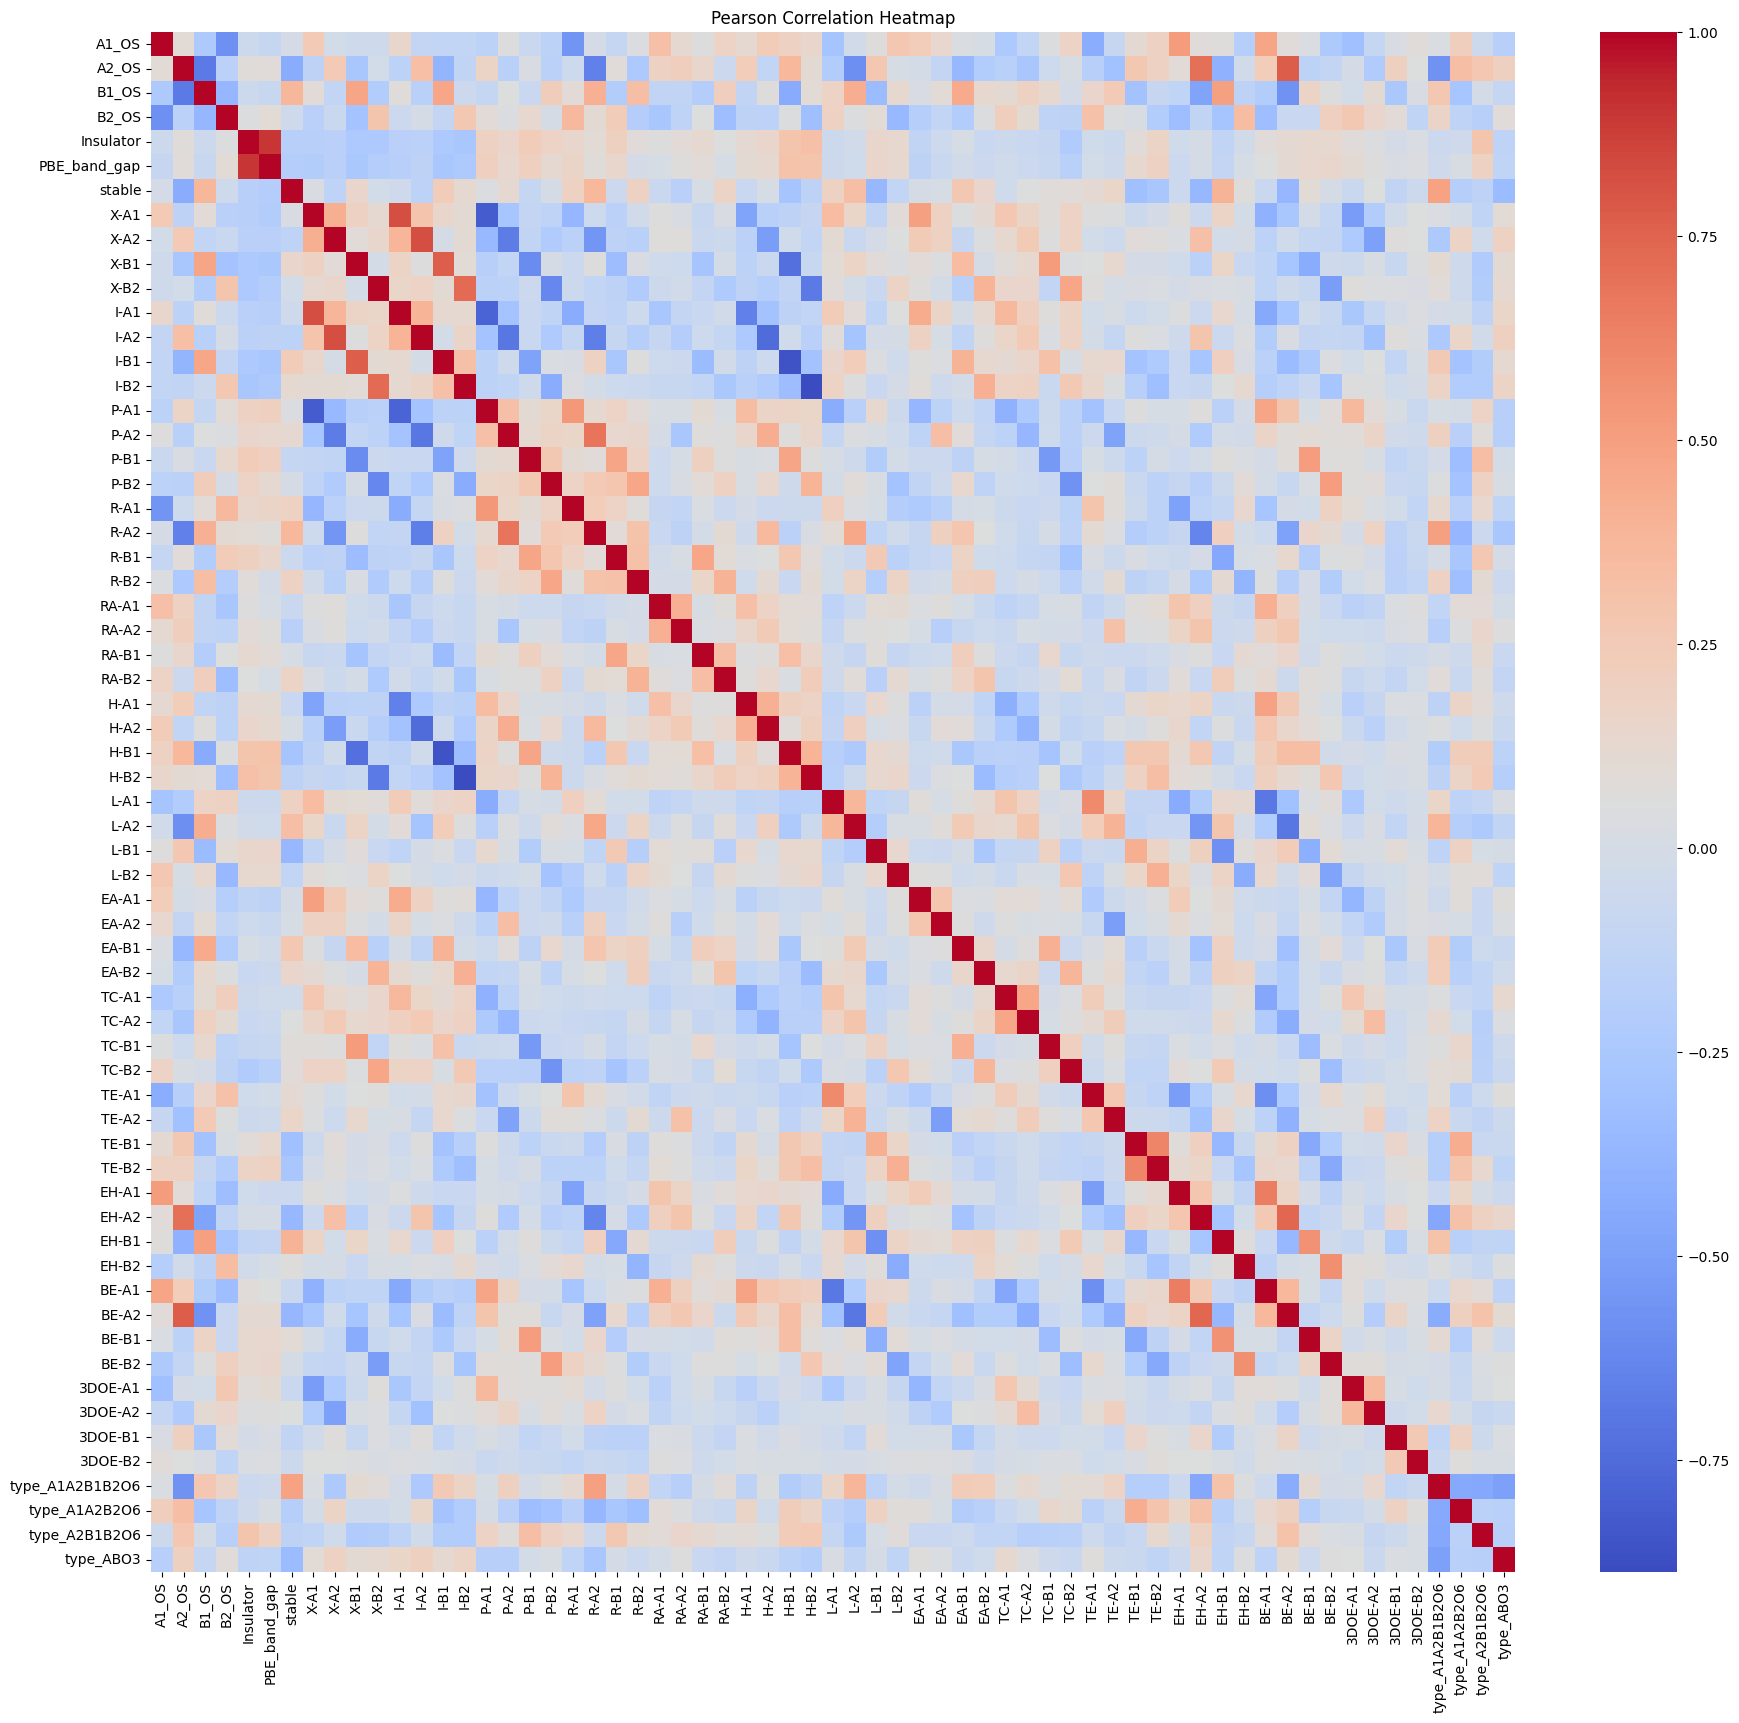

In [5]:
import seaborn as sns

# Calculate correlation matrices
pearson_corr_matrix = df.corr(method='pearson', numeric_only=True)

# Plot Pearson correlation heatmap
plt.figure(figsize=(22, 20))
sns.heatmap(pearson_corr_matrix, cmap='coolwarm', annot=False)
plt.title('Pearson Correlation Heatmap')
plt.show()

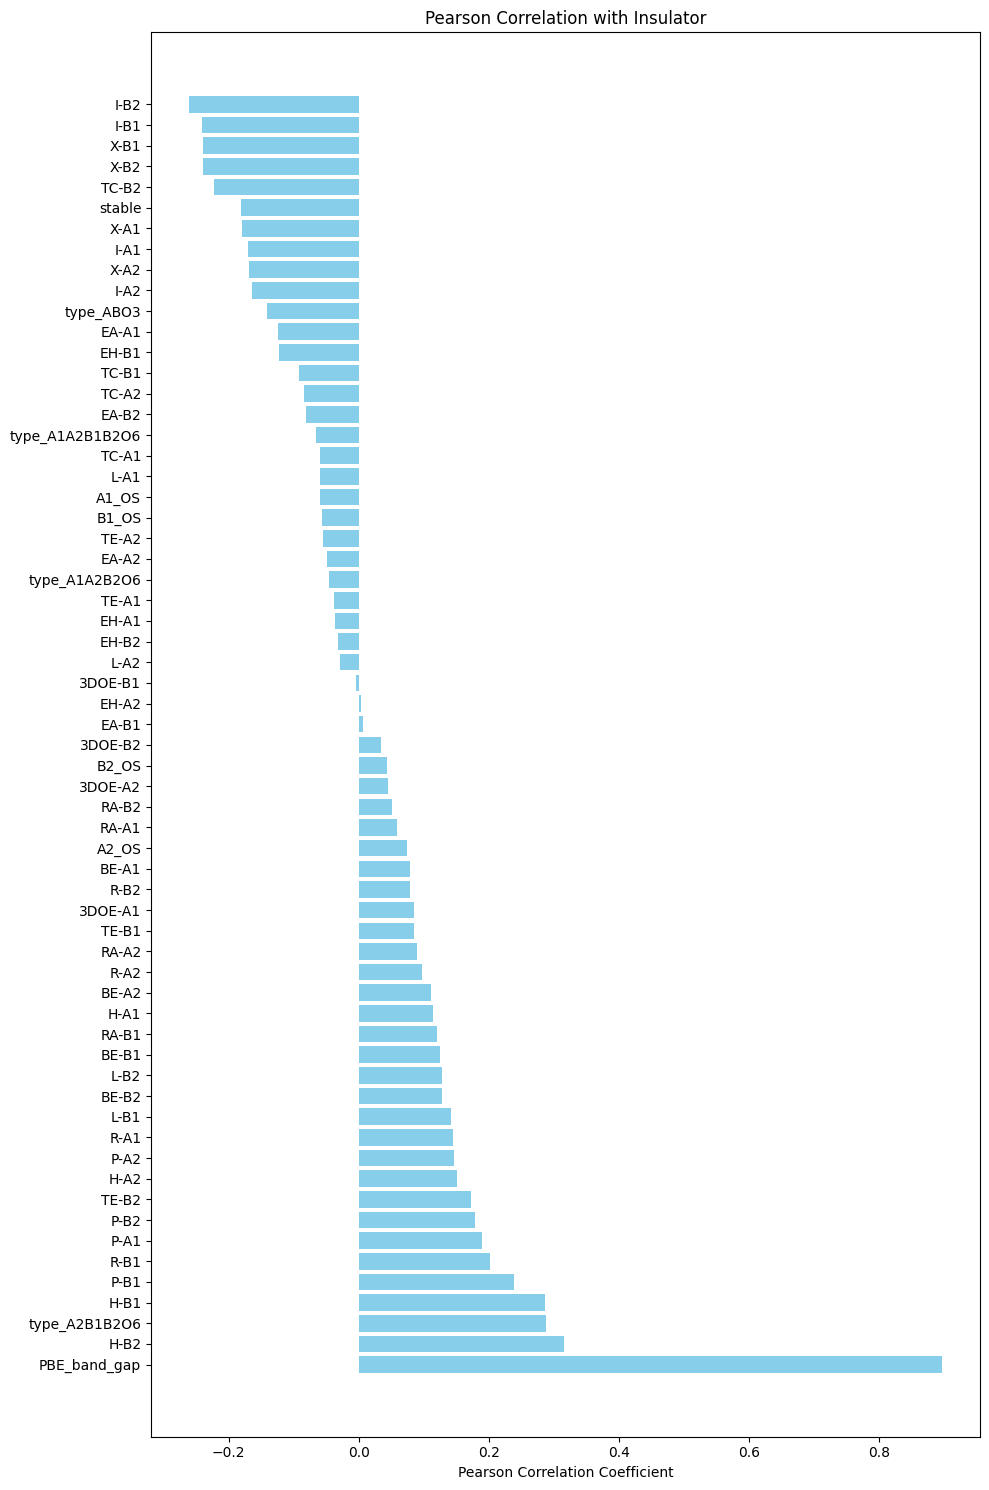

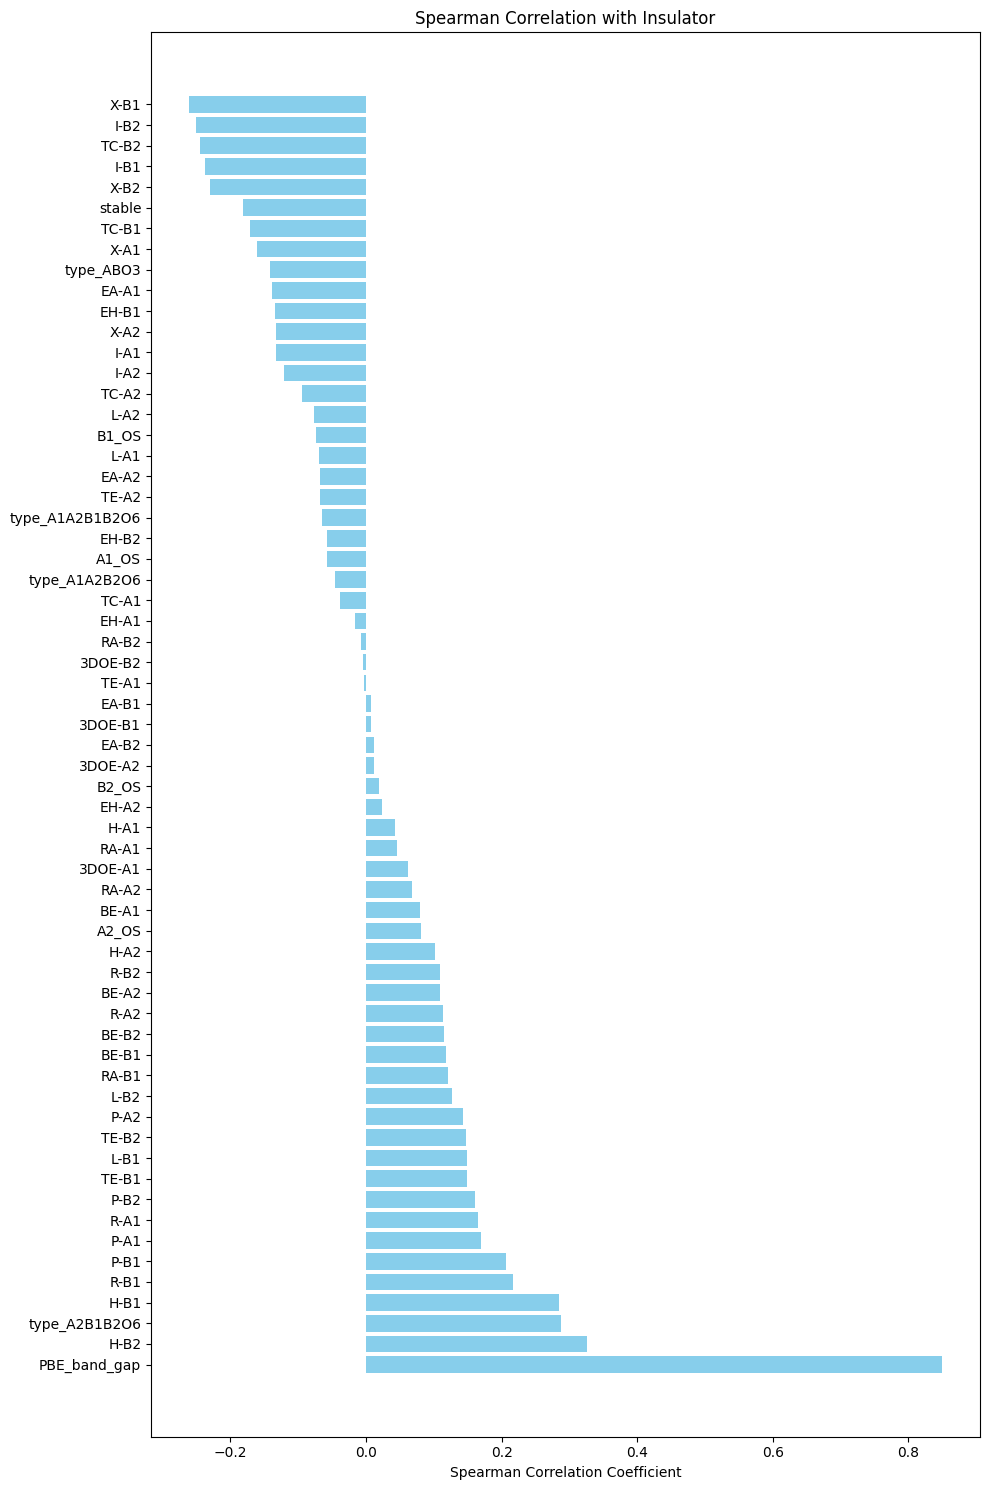

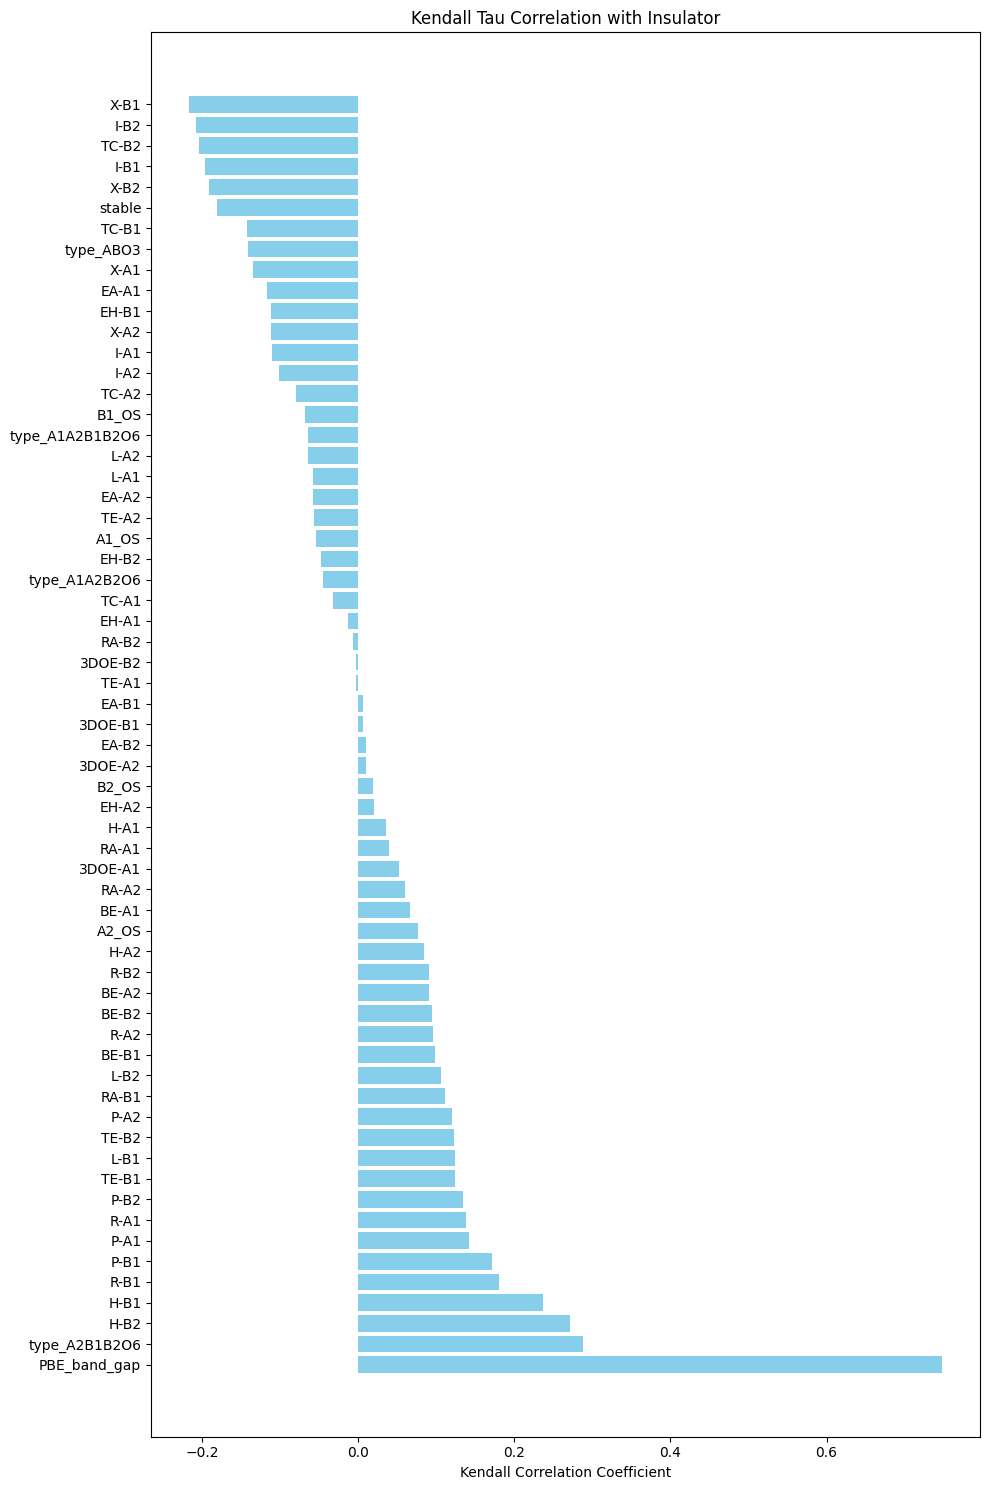

In [6]:
def plot_correlation_barplot(correlation_results, method, title):
    """Plots a horizontal barplot for correlation results."""
    correlations = {col: corrs[method] for col, corrs in correlation_results.items() if corrs[method] is not None}
    sorted_correlations = dict(sorted(correlations.items(), key=lambda item: item[1], reverse=True))

    plt.figure(figsize=(10, 15))
    plt.barh(list(sorted_correlations.keys()), list(sorted_correlations.values()), color='skyblue')
    plt.xlabel(f'{method} Correlation Coefficient')
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_correlation_barplot(correlation_results, 'Pearson', 'Pearson Correlation with Insulator')
plot_correlation_barplot(correlation_results, 'Spearman', 'Spearman Correlation with Insulator')
plot_correlation_barplot(correlation_results, 'Kendall', 'Kendall Tau Correlation with Insulator')

In [7]:
df.drop(columns=['3DOE-B2','EH-A2','EA-B1','PBE_band_gap'], inplace=True)

In [22]:
import random
import warnings
from sklearn.model_selection import train_test_split
from deap import base, creator, tools
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score


# Ignore potential warnings from XGBoost
warnings.filterwarnings('ignore')

# --- Configuration ---
# Order: learning_rate, max_depth, n_estimators, subsample, reg_lambda, reg_alpha, gamma, colsample_bylevel, colsample_bytree
HP_BOUNDS_LOW = [0.01, 3, 50, 0.5, 0, 0, 0, 0.5, 0.5]
HP_BOUNDS_HIGH = [0.3, 15, 500, 1.0, 10, 10, 5, 1.0, 1.0]
# 0: continuous, 1: discrete
HP_TYPES = [0, 1, 1, 0, 0, 0, 0, 0, 0]
NUM_HYPERPARAMETERS = len(HP_BOUNDS_LOW)

# Evolutionary Algorithm Parameters
POPULATION_SIZE = 50
NUM_GENERATIONS = 50
CXPB = 0.7  # Crossover probability
MUTPB = 0.3  # Mutation probability

# --- DEAP Setup ---
creator.create("FitnessMax", base.Fitness, weights=(1.0,))  # maximize accuracy
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

# Attribute generator
def generate_hyperparameter(index):
    low = HP_BOUNDS_LOW[index]
    high = HP_BOUNDS_HIGH[index]
    if HP_TYPES[index] == 0:
        return random.uniform(low, high)
    else:
        return random.randint(low, high)

# Register attribute generators
for i in range(NUM_HYPERPARAMETERS):
    toolbox.register(f"attr_hp{i}", generate_hyperparameter, i)

# Structure initializer
toolbox.register("individual", tools.initCycle, creator.Individual,
                 tuple([toolbox.__getattribute__(f"attr_hp{i}") for i in range(NUM_HYPERPARAMETERS)]), n=1)

toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# --- Evaluation Function ---
def evalXGBC(individual, X_train, y_train, X_val, y_val):
    """Evaluate fitness by training XGBClassifier and returning accuracy."""
    hyperparameters = {
        'learning_rate': individual[0],
        'max_depth': int(individual[1]),
        'n_estimators': int(individual[2]),
        'subsample': individual[3],
        'reg_lambda': individual[4],
        'reg_alpha': individual[5],
        'gamma': individual[6],
        'colsample_bylevel': individual[7],
        'colsample_bytree': individual[8]
    }

    # Ensure valid values
    hyperparameters['max_depth'] = max(1, hyperparameters['max_depth'])
    hyperparameters['n_estimators'] = max(1, hyperparameters['n_estimators'])

    try:
        model = XGBClassifier(
            objective='binary:logistic',
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=42,
            **hyperparameters
        )
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        acc = accuracy_score(y_val, preds)
        return (acc,)
    except Exception:
        return (0.0,)  # worst fitness if training fails

# Placeholder registration
toolbox.register("evaluate", evalXGBC, X_train=None, y_train=None, X_val=None, y_val=None)

# --- Genetic Operators ---
toolbox.register("mate", tools.cxTwoPoint)

def mutate_hyperparameters(individual, mu, sigma, indpb):
    for i, hp_type in enumerate(HP_TYPES):
        if random.random() < indpb:
            if hp_type == 0:
                individual[i] += random.gauss(mu, sigma[i])
                individual[i] = max(HP_BOUNDS_LOW[i], min(HP_BOUNDS_HIGH[i], individual[i]))
            else:
                individual[i] = random.randint(HP_BOUNDS_LOW[i], HP_BOUNDS_HIGH[i])
    return individual,

hp_ranges = [high - low for low, high in zip(HP_BOUNDS_LOW, HP_BOUNDS_HIGH)]
mutation_sigma = [r * 0.1 for r in hp_ranges]
toolbox.register("mutate", mutate_hyperparameters, mu=0, sigma=mutation_sigma, indpb=0.1)

toolbox.register("select", tools.selTournament, tournsize=3)

# --- Evolutionary Algorithm with Early Stopping ---
def eaSimpleWithEarlyStop(population, toolbox, cxpb, mutpb, ngen, stats=None,
                          halloffame=None, verbose=__debug__, patience=5):

    logbook = tools.Logbook()
    logbook.header = ['gen', 'nevals'] + (stats.fields if stats else [])

    # Evaluate the initial population
    fitnesses = list(map(toolbox.evaluate, population))
    for ind, fit in zip(population, fitnesses):
        ind.fitness.values = fit

    if halloffame is not None:
        halloffame.update(population)

    record = stats.compile(population) if stats else {}
    logbook.record(gen=0, nevals=len(population), **record)
    if verbose:
        print(logbook.stream)

    # --- Early stopping vars ---
    best_so_far = max(ind.fitness.values[0] for ind in population)
    no_improve_count = 0

    for gen in range(1, ngen + 1):
        offspring = toolbox.select(population, len(population))
        offspring = list(map(toolbox.clone, offspring))

        # Apply crossover and mutation
        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < cxpb:
                toolbox.mate(child1, child2)
                del child1.fitness.values
                del child2.fitness.values

        for mutant in offspring:
            if random.random() < mutpb:
                toolbox.mutate(mutant)
                del mutant.fitness.values

        # Evaluate invalid individuals
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # Replace population
        population[:] = offspring

        if halloffame is not None:
            halloffame.update(population)

        record = stats.compile(population) if stats else {}
        logbook.record(gen=gen, nevals=len(invalid_ind), **record)
        if verbose:
            print(logbook.stream)

        # --- Early stopping check (maximize) ---
        current_best = max(ind.fitness.values[0] for ind in population)
        if current_best > best_so_far:
            best_so_far = current_best
            no_improve_count = 0
        else:
            no_improve_count += 1

        if no_improve_count >= patience:
            if verbose:
                print(f"\nEarly stopping triggered at generation {gen} "
                      f"(no improvement for {patience} generations).")
            break

    return population, logbook

# --- Main Loop ---
if __name__ == '__main__':


    y_total = df["Insulator"]
    X_total = df.drop(["Insulator"],axis=1)

    X_train, X_test, y_train, y_test = train_test_split(X_total,y_total,test_size=0.2,random_state=101)

   

    toolbox.unregister("evaluate")
    toolbox.register("evaluate", evalXGBC, X_train=X_train, y_train=y_train, X_val=X_test, y_val=y_test)

    print(f"Creating initial population of size {POPULATION_SIZE}...")
    population = toolbox.population(n=POPULATION_SIZE)

    hof = tools.HallOfFame(1)

    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)

    print(f"Starting evolutionary optimization for {NUM_GENERATIONS} generations...")
    population, logbook = eaSimpleWithEarlyStop(population, toolbox, cxpb=CXPB, mutpb=MUTPB,
                                                ngen=NUM_GENERATIONS, stats=stats,
                                                halloffame=hof, verbose=True, patience=5)

    print("\n--- Optimization Results ---")
    if hof:
        best_individual = hof[0]
        best_acc = best_individual.fitness.values[0]
        optimal_hyperparameters = {
            'learning_rate': best_individual[0],
            'max_depth': int(best_individual[1]),
            'n_estimators': int(best_individual[2]),
            'subsample': best_individual[3],
            'reg_lambda': best_individual[4],
            'reg_alpha': best_individual[5],
            'gamma': best_individual[6],
            'colsample_bylevel': best_individual[7],
            'colsample_bytree': best_individual[8]
        }

Creating initial population of size 50...
Starting evolutionary optimization for 50 generations...
gen	nevals	avg     	std     	min     	max     
0  	50    	0.921765	0.013477	0.890398	0.947624
1  	39    	0.932008	0.00865634	0.908826	0.944714
2  	46    	0.937381	0.00520939	0.919496	0.947624
3  	41    	0.941591	0.00330512	0.935015	0.949564
4  	41    	0.942696	0.00305392	0.933075	0.949564
5  	40    	0.942949	0.00410908	0.921435	0.949564
6  	39    	0.94386 	0.00304651	0.934045	0.949564
7  	35    	0.944733	0.00247278	0.938894	0.949564
8  	47    	0.945121	0.00239233	0.938894	0.949564

Early stopping triggered at generation 8 (no improvement for 5 generations).

--- Optimization Results ---


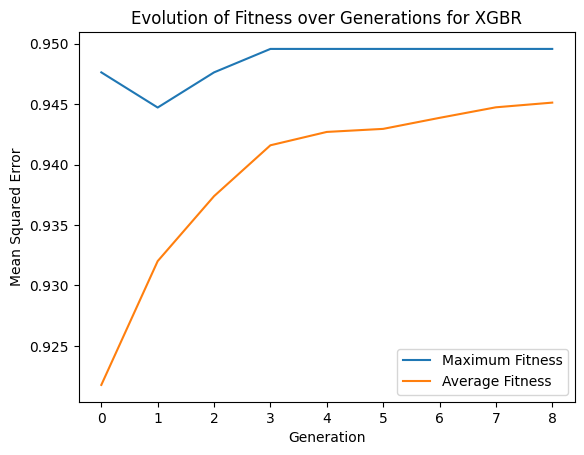

In [23]:
# Plot the statistics
import matplotlib.pyplot as plt
gen = logbook.select("gen")
max_fit = logbook.select("max")
avg_fit = logbook.select("avg")
plt.plot(gen, max_fit, label="Maximum Fitness")
plt.plot(gen, avg_fit, label="Average Fitness")
plt.xlabel("Generation")
plt.ylabel("Mean Squared Error")
plt.title("Evolution of Fitness over Generations for XGBR")
plt.legend()
plt.show()

In [24]:
XGBC_model = XGBClassifier(
            objective='binary:logistic',
            use_label_encoder=False,
            eval_metric='logloss',
            random_state=42,
            **optimal_hyperparameters
        )

XGBC_model.fit(X_train, y_train)
print("\nXGBR model trained with optimal hyperparameters.")
y_pred = XGBC_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_acc:.4f}")


XGBR model trained with optimal hyperparameters.
Test Accuracy: 0.9496


In [25]:
import joblib
import os

model_dir = "../model/insulator"
os.makedirs(model_dir, exist_ok=True)

joblib.dump(XGBC_model, os.path.join(model_dir, "XGBC_model.joblib"))

['../model/insulator/XGBC_model.joblib']

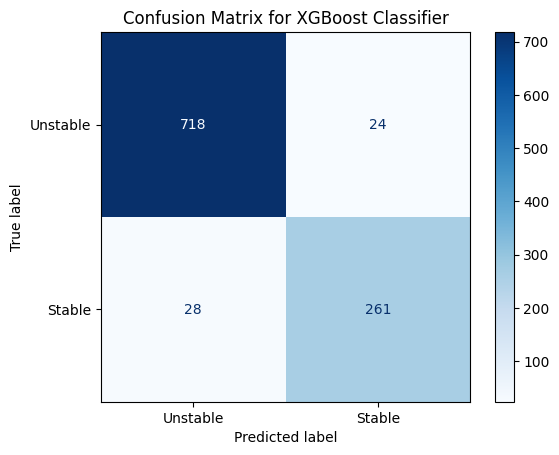

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Unstable", "Stable"], cmap="Blues")
plt.title("Confusion Matrix for XGBoost Classifier")
plt.show()

In [13]:
from sklearn.tree import DecisionTreeClassifier


# Ignore potential warnings
warnings.filterwarnings('ignore')

# --- Configuration for Decision Tree ---
# Order: max_depth, min_samples_split, min_samples_leaf, max_features, criterion, splitter
# For categorical params:
# - max_features options index: [0=None, 1='sqrt', 2='log2']
# - criterion options index: [0='gini', 1='entropy']  # keep to widely compatible options
# - splitter options index: [0='best', 1='random']

HP_BOUNDS_LOW  = [1, 2, 1, 0, 0, 0]
HP_BOUNDS_HIGH = [40, 50, 20, 2, 1, 1]
# 0: continuous, 1: integer, 2: categorical-index (integer but mapped to strings)
HP_TYPES = [1, 1, 1, 2, 2, 2]
NUM_HYPERPARAMETERS = len(HP_BOUNDS_LOW)

MAX_FEATURES_OPTS = [None, 'sqrt', 'log2']
CRITERION_OPTS    = ['gini', 'entropy']
SPLITTER_OPTS     = ['best', 'random']

# --- DEAP Setup ---
creator.create("FitnessMax", base.Fitness, weights=(1.0,))  # maximize accuracy
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

# Attribute generator
def generate_hyperparameter(index):
    low = HP_BOUNDS_LOW[index]
    high = HP_BOUNDS_HIGH[index]
    hp_type = HP_TYPES[index]
    if hp_type == 0:
        return random.uniform(low, high)
    else:
        # both integer and categorical indices use randint for generation
        return random.randint(low, high)

# Register attribute generators
for i in range(NUM_HYPERPARAMETERS):
    toolbox.register(f"attr_hp{i}", generate_hyperparameter, i)

# Structure initializer
toolbox.register(
    "individual",
    tools.initCycle,
    creator.Individual,
    tuple([toolbox.__getattribute__(f"attr_hp{i}") for i in range(NUM_HYPERPARAMETERS)]),
    n=1
)

toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# --- Mapping helper for categorical indices ---
def map_dt_hyperparameters(individual):
    return {
        'max_depth': int(individual[0]),
        'min_samples_split': int(individual[1]),
        'min_samples_leaf': int(individual[2]),
        'max_features': MAX_FEATURES_OPTS[int(individual[3])],
        'criterion': CRITERION_OPTS[int(individual[4])],
        'splitter': SPLITTER_OPTS[int(individual[5])]
    }

# --- Evaluation Function ---
def evalDTC(individual, X_train, y_train, X_val, y_val):
    """Evaluate fitness by training DecisionTreeClassifier and returning accuracy."""
    hp = map_dt_hyperparameters(individual)

    # Ensure valid values
    hp['max_depth'] = max(1, hp['max_depth'])
    hp['min_samples_split'] = max(2, hp['min_samples_split'])
    hp['min_samples_leaf'] = max(1, hp['min_samples_leaf'])

    try:
        model = DecisionTreeClassifier(
            random_state=42,
            **hp
        )
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        acc = accuracy_score(y_val, preds)
        return (acc,)
    except Exception:
        return (0.0,)  # worst fitness if training fails

# Placeholder registration
toolbox.register("evaluate", evalDTC, X_train=None, y_train=None, X_val=None, y_val=None)

# --- Genetic Operators ---
toolbox.register("mate", tools.cxTwoPoint)

def mutate_hyperparameters(individual, mu, sigma, indpb):
    for i, hp_type in enumerate(HP_TYPES):
        if random.random() < indpb:
            if hp_type == 0:
                # continuous (not used here, but kept for pattern consistency)
                individual[i] += random.gauss(mu, sigma[i])
                individual[i] = max(HP_BOUNDS_LOW[i], min(HP_BOUNDS_HIGH[i], individual[i]))
            elif hp_type == 1:
                # integer
                individual[i] = random.randint(HP_BOUNDS_LOW[i], HP_BOUNDS_HIGH[i])
            else:
                # categorical index: resample a valid index
                individual[i] = random.randint(HP_BOUNDS_LOW[i], HP_BOUNDS_HIGH[i])
    return individual,

hp_ranges = [high - low for low, high in zip(HP_BOUNDS_LOW, HP_BOUNDS_HIGH)]
mutation_sigma = [max(1.0, r * 0.1) for r in hp_ranges]  # ensure sigma >= 1 for integer steps
toolbox.register("mutate", mutate_hyperparameters, mu=0, sigma=mutation_sigma, indpb=0.1)

toolbox.register("select", tools.selTournament, tournsize=3)

# --- Evolutionary Algorithm with Early Stopping ---
def eaSimpleWithEarlyStop(population, toolbox, cxpb, mutpb, ngen, stats=None,
                          halloffame=None, verbose=__debug__, patience=5):

    logbook = tools.Logbook()
    logbook.header = ['gen', 'nevals'] + (stats.fields if stats else [])

    # Evaluate the initial population
    fitnesses = list(map(toolbox.evaluate, population))
    for ind, fit in zip(population, fitnesses):
        ind.fitness.values = fit

    if halloffame is not None:
        halloffame.update(population)

    record = stats.compile(population) if stats else {}
    logbook.record(gen=0, nevals=len(population), **record)
    if verbose:
        print(logbook.stream)

    # --- Early stopping vars ---
    best_so_far = max(ind.fitness.values[0] for ind in population)
    no_improve_count = 0

    for gen in range(1, ngen + 1):
        offspring = toolbox.select(population, len(population))
        offspring = list(map(toolbox.clone, offspring))

        # Apply crossover and mutation
        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if random.random() < cxpb:
                toolbox.mate(child1, child2)
                del child1.fitness.values
                del child2.fitness.values

        for mutant in offspring:
            if random.random() < mutpb:
                toolbox.mutate(mutant)
                del mutant.fitness.values

        # Evaluate invalid individuals
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # Replace population
        population[:] = offspring

        if halloffame is not None:
            halloffame.update(population)

        record = stats.compile(population) if stats else {}
        logbook.record(gen=gen, nevals=len(invalid_ind), **record)
        if verbose:
            print(logbook.stream)

        # --- Early stopping check (maximize) ---
        current_best = max(ind.fitness.values[0] for ind in population)
        if current_best > best_so_far:
            best_so_far = current_best
            no_improve_count = 0
        else:
            no_improve_count += 1

        if no_improve_count >= patience:
            if verbose:
                print(f"\nEarly stopping triggered at generation {gen} "
                      f"(no improvement for {patience} generations).")
            break

    return population, logbook

# --- Main Loop ---
if __name__ == '__main__':
    # Expect df with target column "Insulator"
    y_total = df["Insulator"]
    X_total = df.drop(["Insulator"], axis=1)

    X_train, X_test, y_train, y_test = train_test_split(
        X_total, y_total, test_size=0.2, random_state=101, stratify=y_total
    )

    toolbox.unregister("evaluate")
    toolbox.register("evaluate", evalDTC, X_train=X_train, y_train=y_train, X_val=X_test, y_val=y_test)

    POPULATION_SIZE = 50
    NUM_GENERATIONS = 50
    CXPB = 0.7
    MUTPB = 0.3

    print(f"Creating initial population of size {POPULATION_SIZE}...")
    population = toolbox.population(n=POPULATION_SIZE)

    hof = tools.HallOfFame(1)

    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)

    print(f"Starting evolutionary optimization for {NUM_GENERATIONS} generations...")
    population, logbook = eaSimpleWithEarlyStop(
        population, toolbox, cxpb=CXPB, mutpb=MUTPB,
        ngen=NUM_GENERATIONS, stats=stats,
        halloffame=hof, verbose=True, patience=5
    )

    print("\n--- Optimization Results (Decision Tree) ---")
    if hof:
        best_individual = hof[0]
        best_acc = best_individual.fitness.values[0]
        optimal_hyperparameters = map_dt_hyperparameters(best_individual)

        print(f"Best validation accuracy: {best_acc:.4f}")
        print("Best hyperparameters:")
        for k, v in optimal_hyperparameters.items():
            print(f"  {k}: {v}")

        # Train final model on full training data with best params
        final_model = DecisionTreeClassifier(random_state=42, **optimal_hyperparameters)
        final_model.fit(X_train, y_train)
        test_acc = accuracy_score(y_test, final_model.predict(X_test))
        print(f"Final test accuracy: {test_acc:.4f}")

Creating initial population of size 50...
Starting evolutionary optimization for 50 generations...
gen	nevals	avg     	std      	min     	max     
0  	50    	0.826518	0.0411073	0.694471	0.890398
1  	39    	0.857342	0.0229166	0.799224	0.896217
2  	38    	0.87321 	0.0181271	0.817653	0.897187
3  	39    	0.884714	0.00997854	0.835112	0.897187
4  	37    	0.88935 	0.00728377	0.85451 	0.897187
5  	34    	0.892473	0.0105736 	0.833172	0.907856
6  	42    	0.895015	0.00835845	0.870029	0.907856
7  	37    	0.897886	0.00910299	0.86324 	0.913676
8  	44    	0.902502	0.0073721 	0.874879	0.913676
9  	41    	0.904772	0.00899204	0.874879	0.913676
10 	38    	0.910301	0.00281942	0.905917	0.913676
11 	47    	0.910863	0.00770409	0.873909	0.913676
12 	42    	0.911717	0.0080883 	0.873909	0.913676

Early stopping triggered at generation 12 (no improvement for 5 generations).

--- Optimization Results (Decision Tree) ---
Best validation accuracy: 0.9137
Best hyperparameters:
  max_depth: 14
  min_samples_split: 6


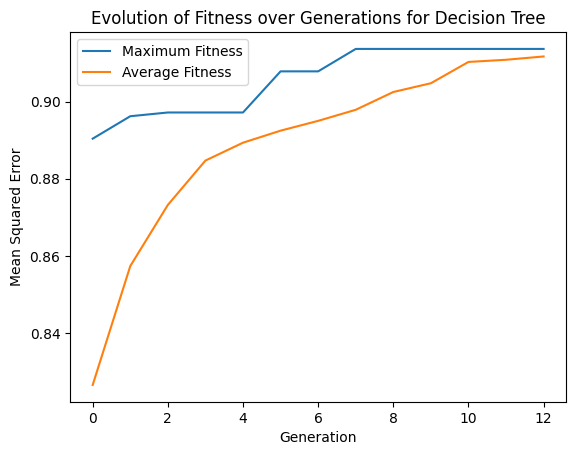

In [18]:
# Plot the statistics
import matplotlib.pyplot as plt
gen = logbook.select("gen")
max_fit = logbook.select("max")
avg_fit = logbook.select("avg")
plt.plot(gen, max_fit, label="Maximum Fitness")
plt.plot(gen, avg_fit, label="Average Fitness")
plt.xlabel("Generation")
plt.ylabel("Mean Squared Error")
plt.title("Evolution of Fitness over Generations for Decision Tree")
plt.legend()
plt.show()

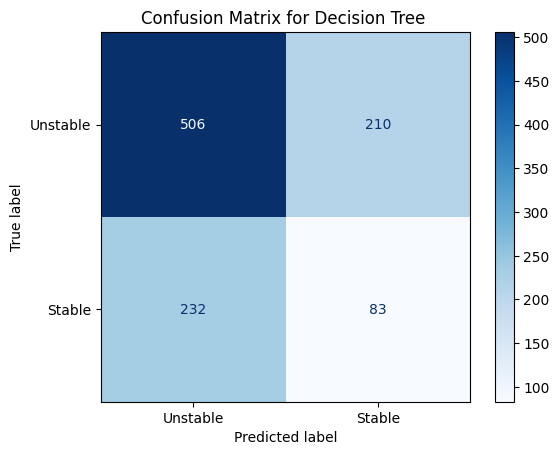

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Unstable", "Stable"], cmap="Blues")
plt.title("Confusion Matrix for Decision Tree ")
plt.show()

In [16]:
joblib.dump(final_model, os.path.join(model_dir, "DT_model.joblib"))

['../model/insulator/DT_model.joblib']